# Hurricane Impact Prediction & Visualization

This notebook trains a neural network to predict county-level hurricane damage from storm and vulnerability features, then provides an interactive map for exploring predictions on real historical storms.

## Workflow
1. **Setup**: install packages, upload data
2. **Data Preparation**: merge the three spreadsheets, define features and targets
3. **Data Exploration**: target distributions and feature correlations
4. **Model Configuration**: hyperparameters, train/test split, model definition
5. **Model Training**: train with sample weighting and plot training curves
6. **Model Evaluation**: R²/RMSE/MAE, predicted-vs-actual, residuals, feature importance
7. **Architecture Comparison**: sweep a few configs to compare
8. **Save Model**: persist the trained weights
9. **Interactive Prediction & Visualization**: pick a real storm, see the predicted impacts on a map

## 1. Setup

Install required packages and import everything used downstream.

In [2]:
# CELL 1: Install and import core libraries

!pip install -q torch torchvision scikit-learn pandas openpyxl matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded. PyTorch version:", torch.__version__)

Libraries loaded. PyTorch version: 2.10.0+cpu


### Upload data files

Upload the three spreadsheets when prompted: a Losses file, a Hazard file, and a Vulnerability file.

In [3]:
# CELL 2: Upload the 3 input spreadsheets

from google.colab import files
print("Upload your 3 xlsx files:")
uploaded = files.upload()

Upload your 3 xlsx files:


Saving Cleaned_County_Losses_Module.xlsx to Cleaned_County_Losses_Module.xlsx
Saving Cleaned_Vulnerability_County Scores.xlsx to Cleaned_Vulnerability_County Scores.xlsx
Saving Cleaned_Hurricane_County_Hazard_Module.xlsx to Cleaned_Hurricane_County_Hazard_Module.xlsx


In [4]:
# CELL 3: Identify each uploaded file by name

LOSSES_PATH = [k for k in uploaded.keys() if 'Losses' in k][0]
HAZARD_PATH = [k for k in uploaded.keys() if 'Hazard' in k][0]
VULN_PATH   = [k for k in uploaded.keys() if 'Vulnerability' in k][0]
print(f"Losses:  {LOSSES_PATH}")
print(f"Hazard:  {HAZARD_PATH}")
print(f"Vuln:    {VULN_PATH}")

Losses:  Cleaned_County_Losses_Module.xlsx
Hazard:  Cleaned_Hurricane_County_Hazard_Module.xlsx
Vuln:    Cleaned_Vulnerability_County Scores.xlsx


## 2. Data Preparation

Load the three spreadsheets and merge them on `(storm, year, county FIPS)`. Then assemble feature and target matrices.

In [6]:
# CELL 4: Load + merge the three datasets

losses = pd.read_excel(LOSSES_PATH)
hazard = pd.read_excel(HAZARD_PATH)
vuln   = pd.read_excel(VULN_PATH)

# Normalize join keys (case + type) so the merge actually matches
losses['_storm'] = losses['Storm Name'].str.upper()
losses['_year']  = losses['Year'].astype('Int64')
losses['_fips']  = losses['STCOFIPS'].astype('Int64')

hazard['_storm'] = hazard['Storm_Name'].str.upper()
hazard['_year']  = hazard['Season'].astype('Int64')
hazard['_fips']  = hazard['FIPS'].astype('Int64')

# Three-way inner join: keep only rows with ALL three datasets present
df = (losses
      .dropna(subset=['STCOFIPS', 'Storm Name', 'Year'])
      .merge(hazard, on=['_fips', '_storm', '_year'], how='inner')
      .merge(vuln, left_on='_fips', right_on='STCOFIPS', how='inner')
)

print(f"Merged dataset: {len(df)} rows, {len(df.columns)} columns")
print(f"   Storms covered: {sorted(df['_storm'].unique())}")
print(f"   Rows dropped (no match): {len(losses.dropna(subset=['STCOFIPS','Storm Name','Year'])) - len(df)}")

Merged dataset: 701 rows, 37 columns
   Storms covered: ['BERYL', 'DEBBY', 'DELTA', 'FLORENCE', 'FRANCINE', 'HARVEY', 'HELENE', 'HERMINE', 'IAN', 'IDA', 'IDALIA', 'IRMA', 'LAURA', 'MATTHEW', 'MICHAEL', 'MILTON', 'NICOLE', 'SALLY', 'ZETA']
   Rows dropped (no match): 56


In [7]:
# CELL 5: Define features (X) and targets (Y)

# 5 damage metrics the model will learn to predict
TARGET_COLS = [
    'Avg Inspected Damage (2024 $)',
    'Registrations / Housing Units',
    'Total Damage / Building Value',
    'Total Damage / Total Value',
    'Major Damage Claims / Housing Units',
]

# Numeric features: storm hazard + county vulnerability + county exposure
NUMERIC_FEATURES = [
    'County_Wind_KT',        # Wind speed experienced by county
    'Storm_Peak_Wind_KT',    # Storm's overall peak wind
    'Storm_Min_Pressure_MB', # Min pressure (proxy for intensity)
    'SOVI_SCORE',            # Social vulnerability index
    'RESL_SCORE',            # Resilience score
    'CRF_VALUE',             # Coastal risk factor
    'BUILDVALUE',            # Total building value ($)
    'AGRIVALUE',             # Agricultural value ($)
    'TOTALVALUE',            # Total property value ($)
    'POPULATION',            # County population
]

# Categorical features will be one-hot encoded
CATEGORICAL_FEATURES = [
    'Storm_Passage_Direction',  # 'direct', 'north', 'south'
    'NOAA_Coastal_Tier',        # Coastal category
]

# Boolean feature
df['Is_Coastal_Shoreline'] = df['Is_Coastal_Shoreline'].astype(int)
BINARY_FEATURES = ['Is_Coastal_Shoreline']

# One-hot encode categoricals
df_encoded = pd.get_dummies(df[CATEGORICAL_FEATURES], drop_first=False)
cat_cols = list(df_encoded.columns)

# Assemble final feature matrix and target matrix
X_raw = pd.concat([
    df[NUMERIC_FEATURES].reset_index(drop=True),
    df[BINARY_FEATURES].reset_index(drop=True),
    df_encoded.reset_index(drop=True)
], axis=1).fillna(0)

Y_raw = df[TARGET_COLS].copy().reset_index(drop=True)

print(f"Features ({X_raw.shape[1]}): {list(X_raw.columns)}")
print(f"\nTargets ({Y_raw.shape[1]}): {TARGET_COLS}")
print(f"\nTarget distributions (raw):")
print(Y_raw.describe().round(4))

Features (16): ['County_Wind_KT', 'Storm_Peak_Wind_KT', 'Storm_Min_Pressure_MB', 'SOVI_SCORE', 'RESL_SCORE', 'CRF_VALUE', 'BUILDVALUE', 'AGRIVALUE', 'TOTALVALUE', 'POPULATION', 'Is_Coastal_Shoreline', 'Storm_Passage_Direction_direct', 'Storm_Passage_Direction_storm_passed_north', 'Storm_Passage_Direction_storm_passed_south', 'NOAA_Coastal_Tier_Coastal Shoreline County', 'NOAA_Coastal_Tier_Inland / Non-Coastal']

Targets (5): ['Avg Inspected Damage (2024 $)', 'Registrations / Housing Units', 'Total Damage / Building Value', 'Total Damage / Total Value', 'Major Damage Claims / Housing Units']

Target distributions (raw):
       Avg Inspected Damage (2024 $)  Registrations / Housing Units  \
count                       701.0000                       701.0000   
mean                       2151.4895                         0.1225   
std                        2232.1398                         0.1355   
min                           0.0000                         0.0000   
25%               

## 3. Data Exploration

Visualize target distributions (raw vs. log-transformed) and feature-target correlations to understand what we're learning.

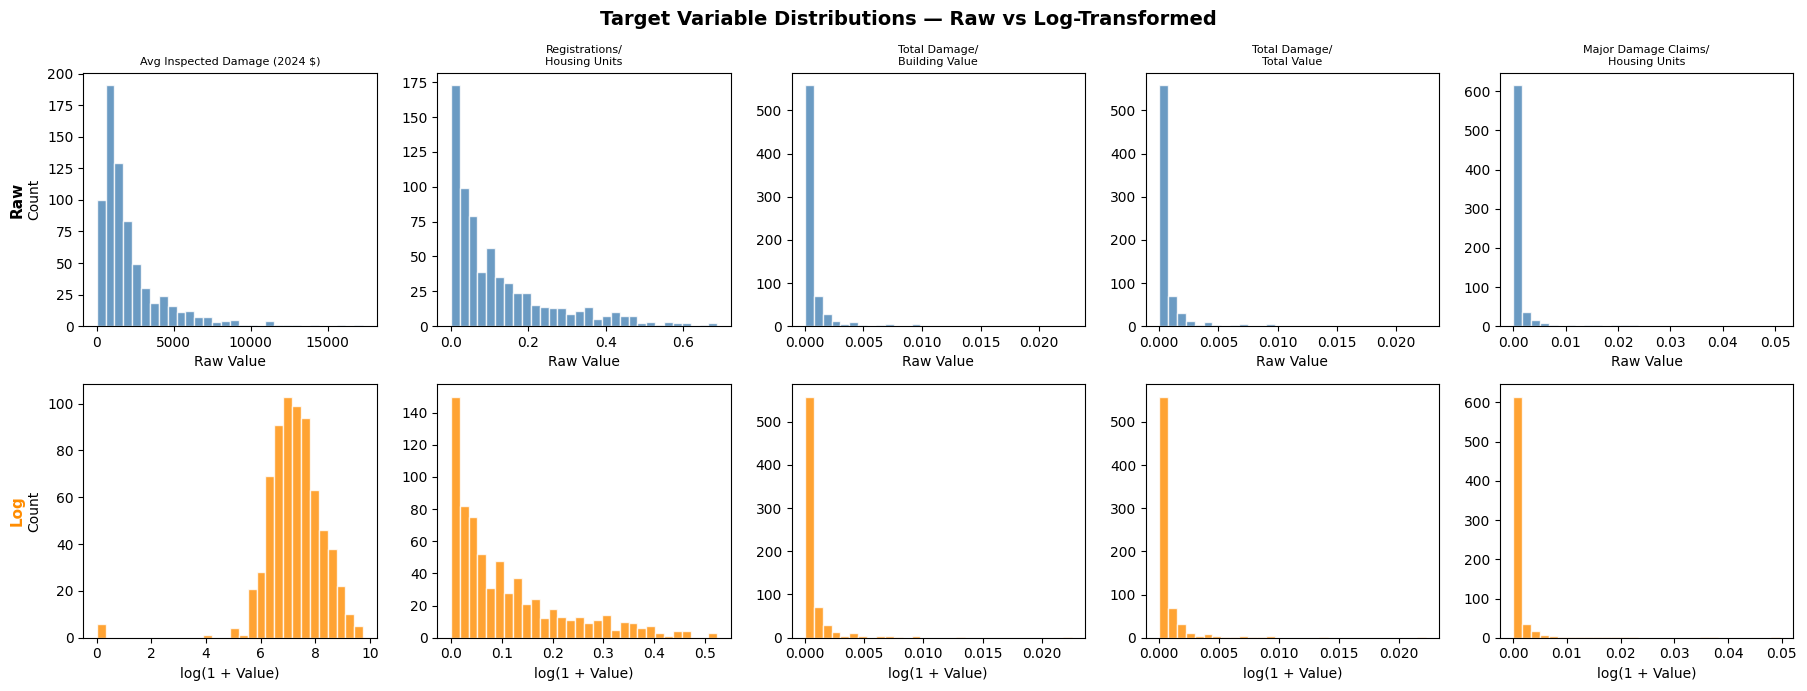

In [9]:
# CELL 6: Plot target distributions — raw vs log-transformed

# Damage metrics are heavily right-skewed. Log-transforming makes them more
# bell-shaped, which is much easier for a neural network to learn.
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle("Target Variable Distributions — Raw vs Log-Transformed", fontsize=14, fontweight='bold')

for i, col in enumerate(TARGET_COLS):
    vals = Y_raw[col].dropna().values
    ax_raw = axes[0, i]
    ax_log = axes[1, i]

    ax_raw.hist(vals, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
    ax_raw.set_title(col.replace(' / ', '/\n'), fontsize=8)
    ax_raw.set_ylabel('Count' if i == 0 else '')
    ax_raw.set_xlabel('Raw Value')

    log_vals = np.log1p(vals)
    ax_log.hist(log_vals, bins=30, color='darkorange', alpha=0.8, edgecolor='white')
    ax_log.set_xlabel('log(1 + Value)')
    ax_log.set_ylabel('Count' if i == 0 else '')

axes[0, 0].text(-0.25, 0.5, 'Raw', transform=axes[0,0].transAxes,
                fontsize=11, fontweight='bold', va='center', rotation=90)
axes[1, 0].text(-0.25, 0.5, 'Log', transform=axes[1,0].transAxes,
                fontsize=11, fontweight='bold', va='center', rotation=90, color='darkorange')
plt.tight_layout()
plt.savefig('target_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

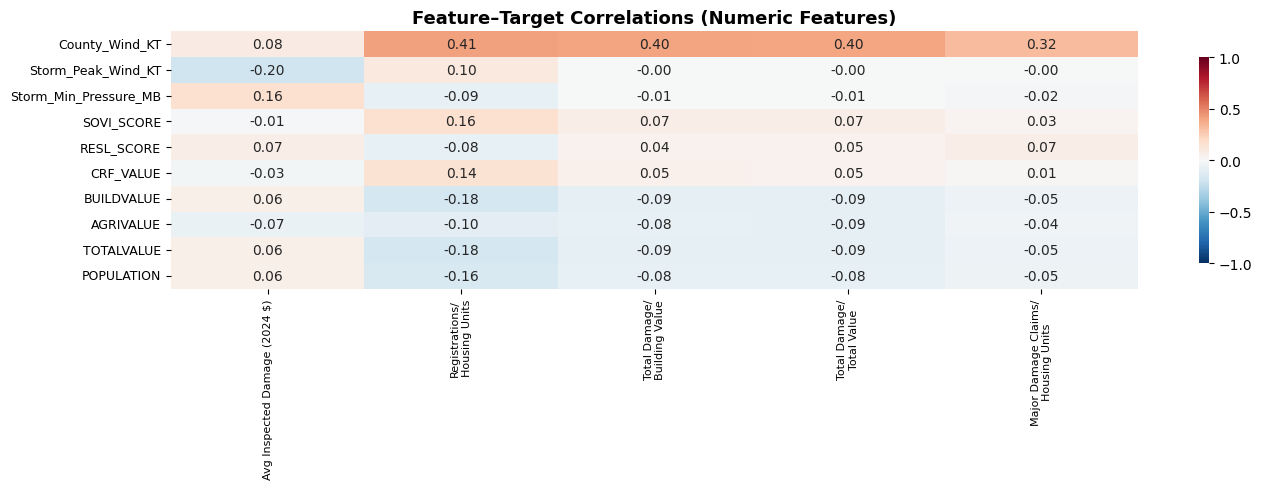

In [10]:
# CELL 7: Feature-target correlation heatmap

# Shows which numeric features have the strongest linear relationships with each target.
fig, ax = plt.subplots(figsize=(14, 5))
corr_data = pd.concat([X_raw[NUMERIC_FEATURES], Y_raw], axis=1).corr()
corr_subset = corr_data.loc[NUMERIC_FEATURES, TARGET_COLS]
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title("Feature–Target Correlations (Numeric Features)", fontsize=13, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_xticklabels([c.replace(' / ','/\n') for c in TARGET_COLS], fontsize=8)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Model Configuration

Set hyperparameters, prepare the train/test split and scaling, then define the neural network.

In [11]:
# CELL 8: Hyperparameters

# All knobs for training are in this single cell. Edit and re-run to retune.

# --- Architecture ---
HIDDEN_LAYERS   = [32]       # Smaller model — less regression-to-mean on small datasets
                                 # Examples to try:
                                 #   [32]           → 1 layer, small
                                 #   [64, 32]       → 2 layers (default)
                                 #   [128, 64, 32]  → 3 layers, larger
                                 #   [256, 128, 64, 32] → 4 layers, large (may overfit)

ACTIVATION      = 'relu'         # Options: 'relu', 'leaky_relu', 'elu', 'tanh'

DROPOUT_RATE    = 0.05           # Fraction of neurons randomly dropped during training
                                 # Range: 0.0 (none) to 0.5 (aggressive regularization)

# --- Training ---
LEARNING_RATE   = 5e-4           # How fast the model updates. Try: 1e-2, 1e-3, 1e-4
BATCH_SIZE      = 32             # Samples per gradient update. Try: 16, 32, 64
EPOCHS          = 300            # Max training iterations
EARLY_STOP_PATIENCE = 300        # no longer want early stop, so equals EPOCHS value

# --- Loss function ---
LOSS_FN         = 'huber'        # Options: 'mse', 'mae', 'huber'
                                 # mse   = penalizes large errors heavily (causes mean-collapse)
                                 # mae   = robust to outliers, treats errors equally
                                 # huber = hybrid; small delta = more MSE-like, large = more MAE-like

# --- Data ---
LOG_TRANSFORM_TARGETS = True     # Strongly recommended True — see Cell 5 for why
SPLIT_BY_STORM  = False          # False = random 80/20 split
                                 # True  = hold out 4 entire storms for test set
                                 #         (more realistic but harder problem)
TEST_STORM_HOLDOUT = ['IAN', 'HELENE', 'HARVEY', 'IRMA']  # Used only if SPLIT_BY_STORM=True
RANDOM_SEED     = 42

# --- L2 Weight Decay (regularization built into optimizer) ---
WEIGHT_DECAY    = 1e-5           # Try: 0, 1e-5, 1e-4, 1e-3

In [13]:
# CELL 9: Prepare data: log transform, split, scale, tensorize

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Apply log transform to targets if enabled
if LOG_TRANSFORM_TARGETS:
    Y = np.log1p(Y_raw.values.astype(float))
    print("Targets log-transformed with log(1 + x)")
else:
    Y = Y_raw.values.astype(float)
    print("Targets NOT log-transformed (raw values)")

X = X_raw.values.astype(float)

# Handle any remaining NaNs
X = np.nan_to_num(X, nan=0.0)
valid_rows = ~np.any(np.isnan(Y), axis=1)
X, Y = X[valid_rows], Y[valid_rows]
storm_ids = df['_storm'].values[valid_rows]
print(f"Samples after NaN removal: {len(X)}")

# Train/test split — either random or hold-out-by-storm
if SPLIT_BY_STORM:
    test_mask = np.isin(storm_ids, TEST_STORM_HOLDOUT)
    train_mask = ~test_mask
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = Y[train_mask], Y[test_mask]
    print(f"\n Storm-based split:")
    print(f"   Train storms: {sorted(set(storm_ids[train_mask]))}")
    print(f"   Test storms:  {sorted(set(storm_ids[test_mask]))}")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y, test_size=0.2, random_state=RANDOM_SEED
    )
    print(f"\n Random 80/20 split:")

print(f"   Train: {len(X_train)} rows | Test: {len(X_test)} rows")

# Scale targets (zero mean, unit variance) — fit only on training
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train)
y_test_scaled  = target_scaler.transform(y_test)

# Scale features the same way
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_scaled,  dtype=torch.float32)

# DataLoader for batching during training
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"\nInput features:  {X_train_s.shape[1]}")
print(f"Output targets:  {y_train.shape[1]}")
print("Data ready for training")

Targets log-transformed with log(1 + x)
Samples after NaN removal: 701

 Random 80/20 split:
   Train: 560 rows | Test: 141 rows

Input features:  16
Output targets:  5
Data ready for training


In [15]:
# CELL 10: Define the neural network, loss, and optimizer

def get_activation(name):
    """Returns the activation module for a given string name."""
    return {
        'relu':       nn.ReLU(),
        'leaky_relu': nn.LeakyReLU(0.1),
        'elu':        nn.ELU(),
        'tanh':       nn.Tanh(),
    }[name]

class HurricaneNet(nn.Module):
    """
    Fully connected neural network for multi-output regression.
    Architecture is configurable via the hyperparameters in Cell 8.
    Each hidden layer applies: Linear → BatchNorm → activation → Dropout.
    The output layer is linear (since this is a regression task).
    """
    def __init__(self, input_dim, output_dim, hidden_layers, activation, dropout_rate):
        super().__init__()
        layers = []
        prev_size = input_dim

        for h_size in hidden_layers:
            layers.append(nn.Linear(prev_size, h_size))
            layers.append(nn.BatchNorm1d(h_size))   # normalize activations per batch
            layers.append(get_activation(activation))
            layers.append(nn.Dropout(p=dropout_rate))
            prev_size = h_size

        layers.append(nn.Linear(prev_size, output_dim))  # output layer: linear (regression)
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# Instantiate
model = HurricaneNet(
    input_dim    = X_train_t.shape[1],
    output_dim   = y_train_t.shape[1],
    hidden_layers = HIDDEN_LAYERS,
    activation   = ACTIVATION,
    dropout_rate = DROPOUT_RATE
)

print("Model Architecture:")
print(model)
print(f"\nTotal trainable parameters: {model.count_parameters():,}")

# Loss function — Huber with smaller delta lets the model venture into high-damage tail
LOSS_MAP = {
    'mse':   nn.MSELoss(),
    'mae':   nn.L1Loss(),
    'huber': nn.HuberLoss(delta=0.2),
}
criterion = LOSS_MAP[LOSS_FN]
HUBER_DELTA = 0.2   # used by the per-sample weighted loss in the training loop

# Optimizer + LR scheduler (drops LR when val loss plateaus)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)

print(f"\n  Loss: {LOSS_FN.upper()} | Optimizer: Adam | LR: {LEARNING_RATE} | Dropout: {DROPOUT_RATE}")

Model Architecture:
HurricaneNet(
  (network): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.05, inplace=False)
    (4): Linear(in_features=32, out_features=5, bias=True)
  )
)

Total trainable parameters: 773

  Loss: HUBER | Optimizer: Adam | LR: 0.0005 | Dropout: 0.05


## 5. Model Training

Train the network with **per-sample weighting**. Counties with high training damage get up-weighted so the model doesn't ignore the high-damage tail (which is exactly the part we care about for hurricane impact prediction).

Best weights (lowest validation loss) are restored after training completes.

In [17]:
# CELL 11: Training loop with weighted loss

def evaluate(model, X_t, y_t):
    """Compute loss in eval mode (no dropout)."""
    model.eval()
    with torch.no_grad():
        pred = model(X_t)
        loss = criterion(pred, y_t).item()
    model.train()
    return loss

# --- Sample weights: counties with high training damage get weighted more, so
#     the model doesn't ignore the rare-but-important high-damage tail. ---
sample_weights = np.abs(y_train_scaled).max(axis=1)        # max scaled magnitude per row
sample_weights = 1.0 + 3.0 * (sample_weights / sample_weights.max())  # scale to range [1, 4]
sample_weights_t = torch.tensor(sample_weights, dtype=torch.float32)

# Rebuild train_loader to also yield weights per batch
weighted_dataset = TensorDataset(X_train_t, y_train_t, sample_weights_t)
train_loader = DataLoader(weighted_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Track losses and best weights
train_losses, val_losses = [], []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f" Training for up to {EPOCHS} epochs...")
print(f"   Loss: {LOSS_FN.upper()} | Sample weighting: ON (range [1, 4])\n")

for epoch in range(1, EPOCHS + 1):
    model.train()
    batch_losses = []
    for X_batch, y_batch, w_batch in train_loader:
        optimizer.zero_grad()
        pred = model(X_batch)

        # Per-sample loss (no reduction), then weight and average
        if LOSS_FN == 'mse':
            per_sample = ((pred - y_batch) ** 2).mean(dim=1)
        elif LOSS_FN == 'mae':
            per_sample = (pred - y_batch).abs().mean(dim=1)
        else:  # huber
            per_sample = torch.nn.functional.huber_loss(
                pred, y_batch, reduction='none', delta=HUBER_DELTA
            ).mean(dim=1)

        loss = (per_sample * w_batch).mean()
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    train_losses.append(np.mean(batch_losses))
    val_loss = evaluate(model, X_test_t, y_test_t)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Track best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train: {train_losses[-1]:.4f} | Val: {val_loss:.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n  Early stopping at epoch {epoch} (no val improvement for {EARLY_STOP_PATIENCE} epochs)")
        break

# Restore the best weights seen during training
if best_model_state is not None:
    model.load_state_dict(best_model_state)
print(f"\n Training complete. Best val loss: {best_val_loss:.4f}")

 Training for up to 300 epochs...
   Loss: HUBER | Sample weighting: ON (range [1, 4])

Epoch   1 | Train: 0.1220 | Val: 0.0900 | LR: 0.000000
Epoch  10 | Train: 0.1202 | Val: 0.0898 | LR: 0.000000
Epoch  20 | Train: 0.1197 | Val: 0.0900 | LR: 0.000000
Epoch  30 | Train: 0.1210 | Val: 0.0899 | LR: 0.000000
Epoch  40 | Train: 0.1196 | Val: 0.0899 | LR: 0.000000
Epoch  50 | Train: 0.1214 | Val: 0.0899 | LR: 0.000000
Epoch  60 | Train: 0.1216 | Val: 0.0899 | LR: 0.000000
Epoch  70 | Train: 0.1181 | Val: 0.0900 | LR: 0.000000
Epoch  80 | Train: 0.1244 | Val: 0.0902 | LR: 0.000000
Epoch  90 | Train: 0.1191 | Val: 0.0899 | LR: 0.000000
Epoch 100 | Train: 0.1179 | Val: 0.0900 | LR: 0.000000
Epoch 110 | Train: 0.1218 | Val: 0.0899 | LR: 0.000000
Epoch 120 | Train: 0.1200 | Val: 0.0900 | LR: 0.000000
Epoch 130 | Train: 0.1192 | Val: 0.0899 | LR: 0.000000
Epoch 140 | Train: 0.1288 | Val: 0.0898 | LR: 0.000000
Epoch 150 | Train: 0.1210 | Val: 0.0900 | LR: 0.000000
Epoch 160 | Train: 0.1196 | Val:

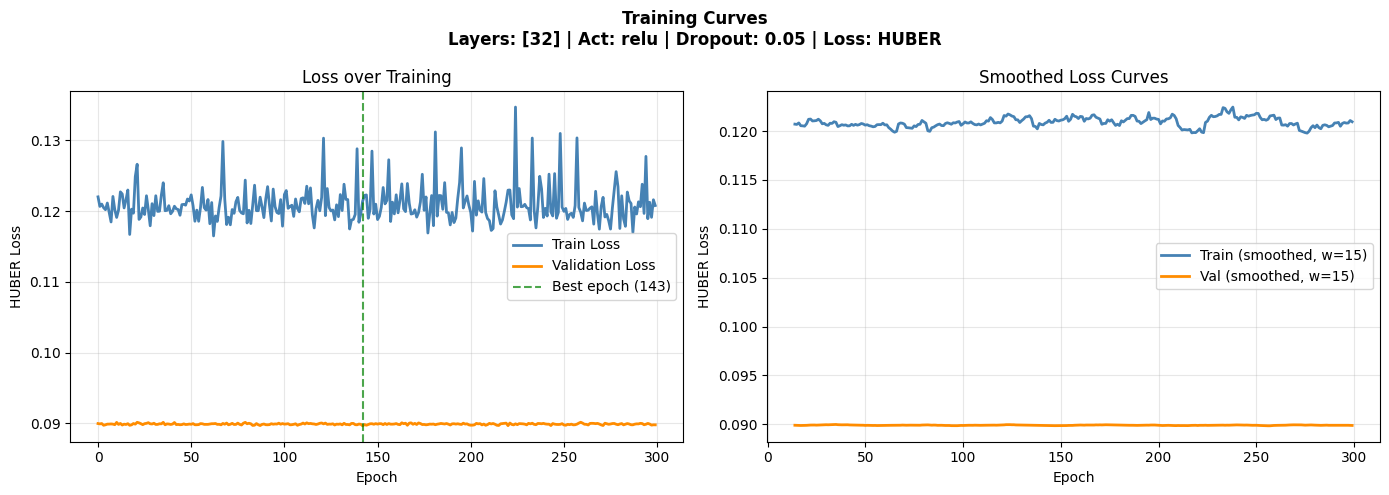


 Overfitting check — final train/val gap: -0.03098
   (Large positive gap = overfitting; try more dropout or L2 regularization)


In [18]:
# CELL 12: Plot training curves

# Look for: (a) val loss decreasing alongside train loss = good
#           (b) val loss climbing while train loss falls = overfitting
stopped_epoch = len(train_losses)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

config_label = f"Layers: {HIDDEN_LAYERS} | Act: {ACTIVATION} | Dropout: {DROPOUT_RATE} | Loss: {LOSS_FN.upper()}"
fig.suptitle(f"Training Curves\n{config_label}", fontsize=12, fontweight='bold')

# Main loss curves
ax1.plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
ax1.plot(val_losses,   label='Validation Loss', color='darkorange', linewidth=2)
ax1.axvline(x=np.argmin(val_losses), color='green', linestyle='--', alpha=0.7,
            label=f'Best epoch ({np.argmin(val_losses)+1})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel(f'{LOSS_FN.upper()} Loss')
ax1.set_title('Loss over Training')
ax1.legend()
ax1.grid(alpha=0.3)

# Smoothed version (moving average) — easier to see the trend
window = max(1, stopped_epoch // 20)
train_smooth = pd.Series(train_losses).rolling(window).mean()
val_smooth   = pd.Series(val_losses).rolling(window).mean()
ax2.plot(train_smooth, label=f'Train (smoothed, w={window})', color='steelblue', linewidth=2)
ax2.plot(val_smooth,   label=f'Val (smoothed, w={window})', color='darkorange', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel(f'{LOSS_FN.upper()} Loss')
ax2.set_title('Smoothed Loss Curves')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

gap = np.array(val_losses) - np.array(train_losses)
print(f"\n Overfitting check — final train/val gap: {gap[-1]:.5f}")
print("   (Large positive gap = overfitting; try more dropout or L2 regularization)")

## 6. Model Evaluation

Compute test-set metrics (R², RMSE, MAE per target), then visualize predicted-vs-actual scatter plots, residuals, and feature importance.

In [19]:
# CELL 13: Compute per-target test metrics

# All metrics computed in the original target units (after un-scaling and un-logging).
model.eval()
with torch.no_grad():
    y_pred_log = model(X_test_t).numpy()
    y_true_log = y_test_t.numpy()

# Reverse scaling, then reverse log transform
if LOG_TRANSFORM_TARGETS:
    y_pred_log = target_scaler.inverse_transform(y_pred_log)
    y_true_log = target_scaler.inverse_transform(y_true_log)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_true_log)
else:
    y_pred_log = target_scaler.inverse_transform(y_pred_log)
    y_true_log = target_scaler.inverse_transform(y_true_log)
    y_pred = y_pred_log
    y_true = y_true_log

# Per-target metrics
results = {}
print(f"\n{'Target':<40} {'R²':>7} {'RMSE':>12} {'MAE':>12}")
print("-" * 73)
for i, col in enumerate(TARGET_COLS):
    r2   = r2_score(y_true[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
    mae  = mean_absolute_error(y_true[:, i], y_pred[:, i])
    results[col] = {'R2': r2, 'RMSE': rmse, 'MAE': mae}
    print(f"{col:<40} {r2:>7.3f} {rmse:>12.4f} {mae:>12.4f}")

print("\n R² interpretation: 1.0 = perfect, 0.0 = no better than predicting the mean, <0 = worse than mean")


Target                                        R²         RMSE          MAE
-------------------------------------------------------------------------
Avg Inspected Damage (2024 $)              0.023    2503.7449    1421.3269
Registrations / Housing Units              0.318       0.1113       0.0722
Total Damage / Building Value              0.199       0.0020       0.0006
Total Damage / Total Value                 0.206       0.0019       0.0006
Major Damage Claims / Housing Units        0.078       0.0054       0.0014

 R² interpretation: 1.0 = perfect, 0.0 = no better than predicting the mean, <0 = worse than mean


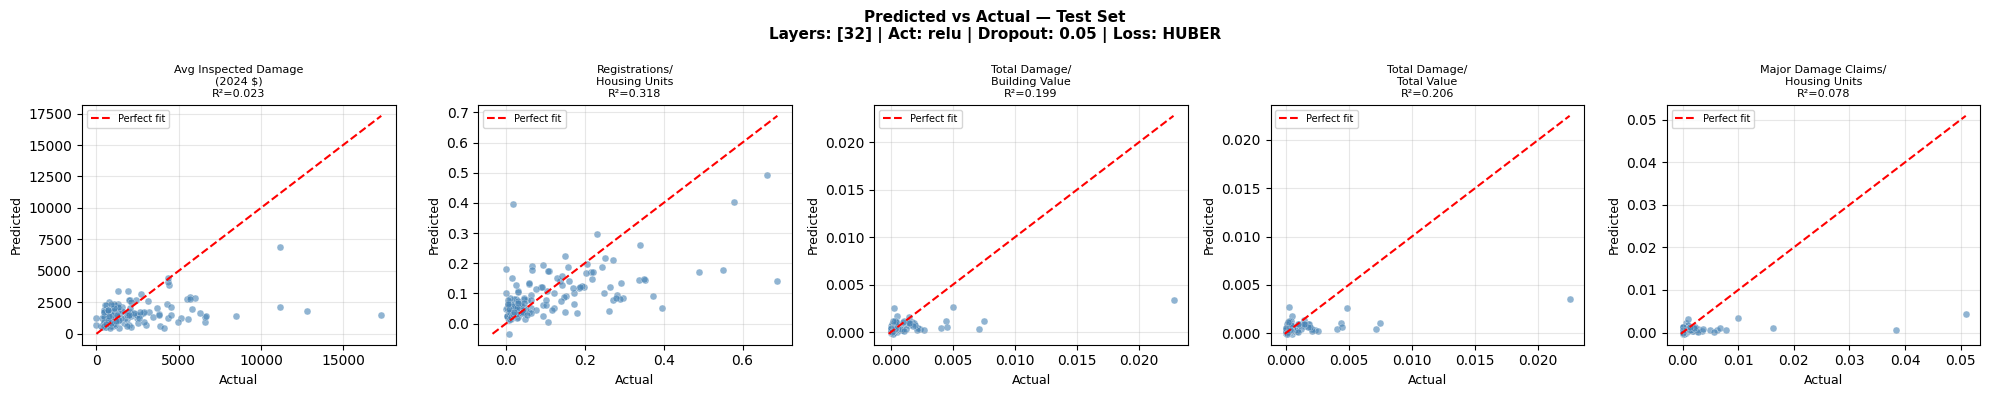

In [20]:
# CELL 14: Predicted vs Actual scatter plots

# Points should cluster around the red diagonal. Wide vertical spread = noisy predictions.
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle(f"Predicted vs Actual — Test Set\n{config_label}", fontsize=11, fontweight='bold')

for i, col in enumerate(TARGET_COLS):
    ax = axes[i]
    ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.6, s=25, color='steelblue', edgecolors='white', linewidth=0.3)
    lim_min = min(y_true[:, i].min(), y_pred[:, i].min())
    lim_max = max(y_true[:, i].max(), y_pred[:, i].max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual', fontsize=9)
    ax.set_ylabel('Predicted', fontsize=9)
    short = col.replace(' / ', '/\n').replace(' (2024 $)', '\n(2024 $)')
    ax.set_title(f"{short}\nR²={results[col]['R2']:.3f}", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

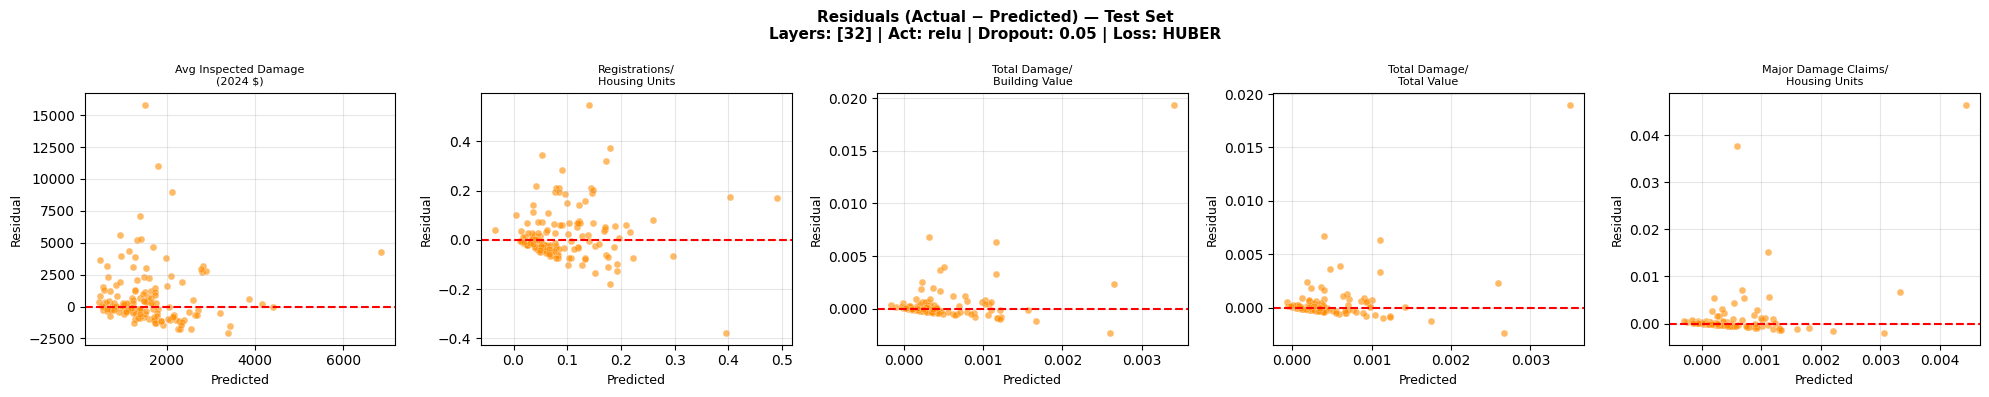

Ideal residuals: randomly scattered around 0. Patterns = systematic error.


In [22]:
# CELL 15: Residual plots

# Residual = (actual − predicted). Ideal: random scatter around zero.
# Patterns (e.g. fanning out, systematic bias) indicate the model is missing something.
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle(f"Residuals (Actual − Predicted) — Test Set\n{config_label}", fontsize=11, fontweight='bold')

for i, col in enumerate(TARGET_COLS):
    residuals = y_true[:, i] - y_pred[:, i]
    ax = axes[i]
    ax.scatter(y_pred[:, i], residuals, alpha=0.6, s=25, color='darkorange', edgecolors='white', linewidth=0.3)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Residual', fontsize=9)
    short = col.replace(' / ', '/\n').replace(' (2024 $)', '\n(2024 $)')
    ax.set_title(short, fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Ideal residuals: randomly scattered around 0. Patterns = systematic error.")

Computing feature importance (this takes ~30 seconds)...


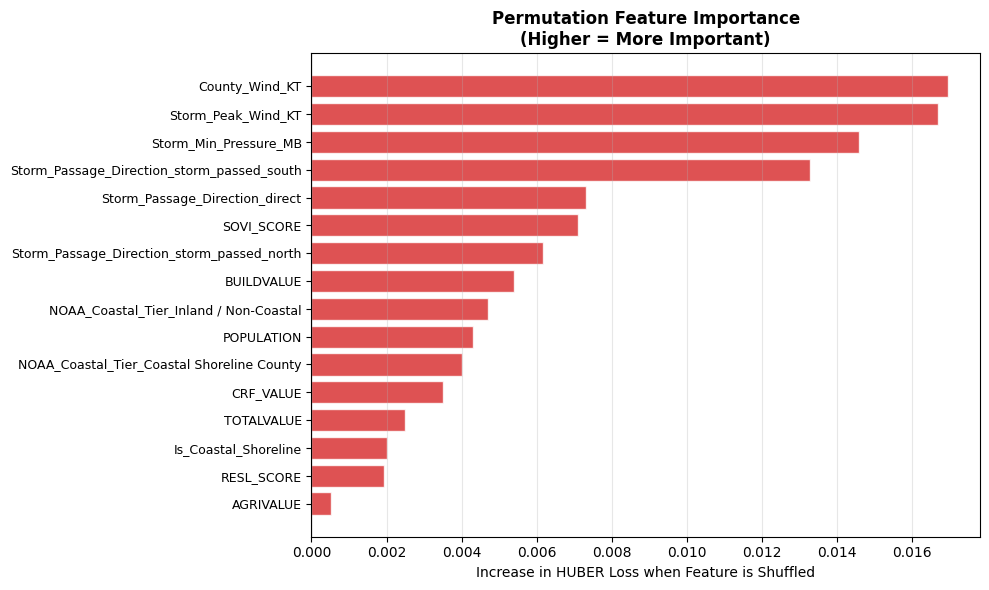

In [23]:
# CELL 16: Permutation feature importance

# Shuffle each feature one at a time and measure how much loss gets worse.
# Bigger jump = the model relies on that feature more.
def permutation_importance(model, X_t, y_t, n_repeats=10):
    baseline = evaluate(model, X_t, y_t)
    importances = []
    for j in range(X_t.shape[1]):
        scores = []
        for _ in range(n_repeats):
            X_perm = X_t.clone()
            idx = torch.randperm(X_t.shape[0])
            X_perm[:, j] = X_t[idx, j]
            scores.append(evaluate(model, X_perm, y_t))
        importances.append(np.mean(scores) - baseline)
    return np.array(importances)

print("Computing feature importance (this takes ~30 seconds)...")
importances = permutation_importance(model, X_test_t, y_test_t, n_repeats=15)
feature_names = list(X_raw.columns)

fig, ax = plt.subplots(figsize=(10, 6))
sorted_idx = np.argsort(importances)
colors = ['#d62728' if imp > 0 else '#1f77b4' for imp in importances[sorted_idx]]
bars = ax.barh(range(len(sorted_idx)), importances[sorted_idx], color=colors, alpha=0.8, edgecolor='white')
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=9)
ax.set_xlabel(f'Increase in {LOSS_FN.upper()} Loss when Feature is Shuffled', fontsize=10)
ax.set_title('Permutation Feature Importance\n(Higher = More Important)', fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Architecture Comparison

Sweeps a few architectures and compares them on the same train/test split. Useful for picking a configuration but not required to use the model. Skip to Section 8 if you're happy with the current one.

In [25]:
# CELL 17: Define the comparison-training helper

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def train_and_evaluate(config, verbose=False):
    """Train one model with the given config and return test metrics."""
    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    m = HurricaneNet(
        input_dim     = X_train_t.shape[1],
        output_dim    = y_train_t.shape[1],
        hidden_layers = config['hidden_layers'],
        activation    = config['activation'],
        dropout_rate  = config['dropout_rate'],
    )

    loss_map = {'mse': nn.MSELoss(), 'mae': nn.L1Loss(), 'huber': nn.HuberLoss(delta=1.0)}
    crit = loss_map[config['loss_fn']]
    opt = torch.optim.Adam(m.parameters(), lr=config['learning_rate'],
                           weight_decay=config['weight_decay'])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)

    loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                        batch_size=config['batch_size'], shuffle=True)

    def eval_loss(X_t, y_t):
        m.eval()
        with torch.no_grad():
            return crit(m(X_t), y_t).item()

    best_val = float('inf')
    patience = 0
    best_state = None
    train_curve, val_curve = [], []

    for epoch in range(1, config['epochs'] + 1):
        m.train()
        batch_losses = []
        for Xb, yb in loader:
            opt.zero_grad()
            loss = crit(m(Xb), yb)
            loss.backward()
            opt.step()
            batch_losses.append(loss.item())

        tr_loss = np.mean(batch_losses)
        v_loss = eval_loss(X_test_t, y_test_t)
        train_curve.append(tr_loss)
        val_curve.append(v_loss)
        sched.step(v_loss)

        if v_loss < best_val:
            best_val = v_loss
            patience = 0
            best_state = {k: v.clone() for k, v in m.state_dict().items()}
        else:
            patience += 1
        if patience >= config['early_stop_patience']:
            if verbose: print(f"  Early stop at epoch {epoch}")
            break

    m.load_state_dict(best_state)

    # Evaluate on test set in original units
    m.eval()
    with torch.no_grad():
        y_pred_scaled = m(X_test_t).numpy()
        y_true_scaled = y_test_t.numpy()
    y_pred_un = target_scaler.inverse_transform(y_pred_scaled)
    y_true_un = target_scaler.inverse_transform(y_true_scaled)
    if LOG_TRANSFORM_TARGETS:
        y_pred_final = np.expm1(y_pred_un)
        y_true_final = np.expm1(y_true_un)
    else:
        y_pred_final = y_pred_un
        y_true_final = y_true_un

    metrics = {}
    for i, col in enumerate(TARGET_COLS):
        metrics[col] = {
            'R2':   r2_score(y_true_final[:, i], y_pred_final[:, i]),
            'RMSE': np.sqrt(mean_squared_error(y_true_final[:, i], y_pred_final[:, i])),
            'MAE':  mean_absolute_error(y_true_final[:, i], y_pred_final[:, i]),
        }
    metrics['_mean_R2']    = np.mean([metrics[c]['R2'] for c in TARGET_COLS])
    metrics['_n_params']   = sum(p.numel() for p in m.parameters() if p.requires_grad)
    metrics['_epochs']     = len(train_curve)
    metrics['_final_val']  = best_val
    return metrics

print("train_and_evaluate function defined")

train_and_evaluate function defined


In [28]:
# CELL 18: Run the experiments

# Each experiment changes ONE thing from the baseline.

base = {
    'hidden_layers':       [256, 128, 64, 32],   # current baseline
    'activation':          'relu',
    'dropout_rate':        0.1,
    'learning_rate':       5e-4,
    'batch_size':          32,
    'epochs':              300,
    'early_stop_patience': 30,
    'loss_fn':             'huber',
    'weight_decay':        1e-5,
}

experiments = {
    'Baseline [256,128,64,32]':  base,
    'Smaller [64,32]':           {**base, 'hidden_layers': [64, 32]},
    'High dropout (0.3)':        {**base, 'dropout_rate': 0.3},
    'MSE loss':                  {**base, 'loss_fn': 'mse'},
}

all_results = {}
for name, cfg in experiments.items():
    print(f"{name} ...", end=' ', flush=True)
    metrics = train_and_evaluate(cfg)
    all_results[name] = metrics
    print(f"mean R²={metrics['_mean_R2']:.3f} | params={metrics['_n_params']:,} | epochs={metrics['_epochs']}")

print("\n All experiments done")

Baseline [256,128,64,32] ... mean R²=0.295 | params=48,709 | epochs=100
Smaller [64,32] ... mean R²=0.281 | params=3,525 | epochs=167
High dropout (0.3) ... mean R²=0.237 | params=48,709 | epochs=94
MSE loss ... mean R²=0.344 | params=48,709 | epochs=104

 All experiments done


 Model Comparison (sorted by mean R²):

                   Model  Mean R²  Params  Epochs  R²: Avg Inspected Dama  R²: Registrations  R²: Total Damage  R²: Major Damage Claim
                MSE loss 0.344435   48709     104                0.069140           0.323933          0.476589                0.372123
Baseline [256,128,64,32] 0.295287   48709     100                0.115299           0.350762          0.378650                0.253501
         Smaller [64,32] 0.280510    3525     167                0.083138           0.372279          0.358854                0.222807
      High dropout (0.3) 0.237081   48709      94                0.070359           0.336901          0.303431                0.167951

 Saved: model_comparison.csv


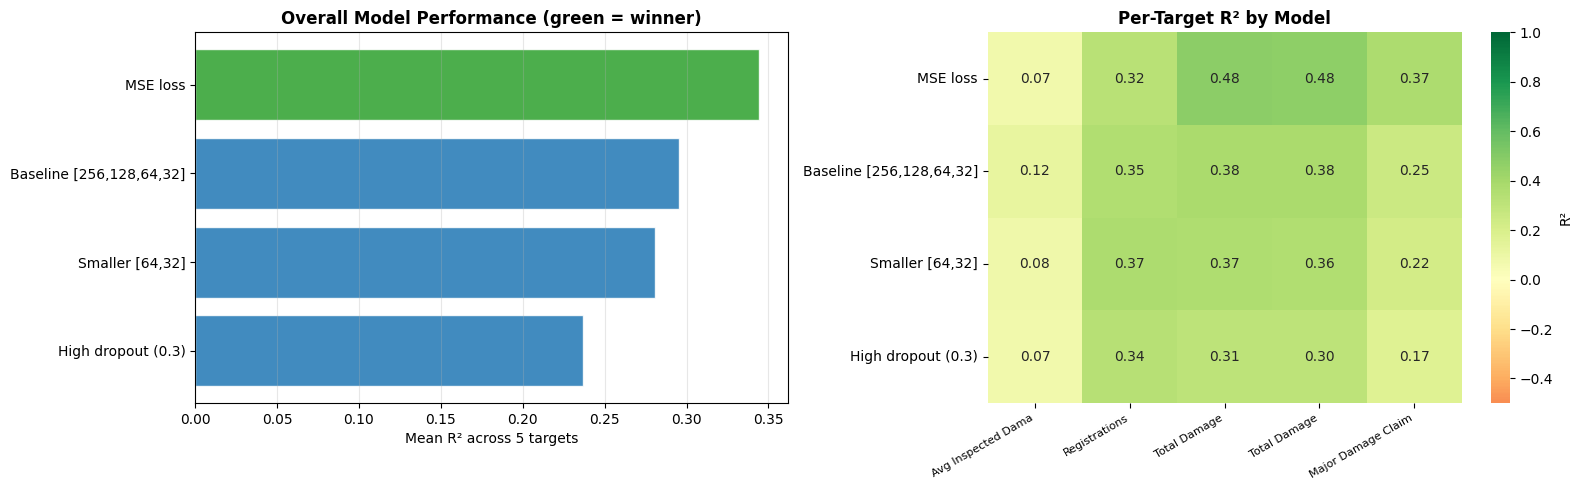


 Best model: MSE loss  (mean R² = 0.344)
   Architecture: [256, 128, 64, 32]
   Activation: relu
   Dropout: 0.1
   Loss: mse
   Weight decay: 1e-05


In [29]:
# CELL 19: Summary table, bar chart, and per-target heatmap

import pandas as pd

# Build summary table
rows = []
for name, m in all_results.items():
    row = {'Model': name, 'Mean R²': m['_mean_R2'],
           'Params': m['_n_params'], 'Epochs': m['_epochs']}
    for col in TARGET_COLS:
        short = col.split('/')[0].strip()[:18]
        row[f'R²: {short}'] = m[col]['R2']
    rows.append(row)

summary_df = pd.DataFrame(rows).sort_values('Mean R²', ascending=False).reset_index(drop=True)
print(" Model Comparison (sorted by mean R²):\n")
print(summary_df.to_string(index=False))
summary_df.to_csv('model_comparison.csv', index=False)
print("\n Saved: model_comparison.csv")

# Bar chart of mean R² + heatmap of per-target R²
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
sorted_items = sorted(all_results.items(), key=lambda x: x[1]['_mean_R2'], reverse=True)
names = [n for n, _ in sorted_items]
mean_r2s = [m['_mean_R2'] for _, m in sorted_items]
colors = ['#2ca02c' if r == max(mean_r2s) else '#1f77b4' for r in mean_r2s]
ax.barh(names, mean_r2s, color=colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('Mean R² across 5 targets')
ax.set_title('Overall Model Performance (green = winner)', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

ax = axes[1]
heat = np.array([[all_results[n][col]['R2'] for col in TARGET_COLS] for n in names])
short_targets = [c.split('/')[0].strip()[:18] for c in TARGET_COLS]
sns.heatmap(heat, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            vmin=-0.5, vmax=1.0, xticklabels=short_targets, yticklabels=names,
            ax=ax, cbar_kws={'label': 'R²'})
ax.set_title('Per-Target R² by Model', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

winner = sorted_items[0]
winner_cfg = experiments[winner[0]]
print(f"\n Best model: {winner[0]}  (mean R² = {winner[1]['_mean_R2']:.3f})")
print(f"   Architecture: {winner_cfg['hidden_layers']}")
print(f"   Activation: {winner_cfg['activation']}")
print(f"   Dropout: {winner_cfg['dropout_rate']}")
print(f"   Loss: {winner_cfg['loss_fn']}")
print(f"   Weight decay: {winner_cfg['weight_decay']}")

## 8. Save Model

Persist the trained model, scalers, and config so the prediction section can reload it without retraining.

In [30]:
# CELL 20: Save trained model + results

torch.save({
    'model_state': model.state_dict(),
    'scaler_mean': scaler.mean_,
    'scaler_scale': scaler.scale_,
    'config': {
        'hidden_layers': HIDDEN_LAYERS,
        'activation': ACTIVATION,
        'dropout_rate': DROPOUT_RATE,
        'log_transform': LOG_TRANSFORM_TARGETS,
        'feature_cols': list(X_raw.columns),
        'target_cols': TARGET_COLS,
    },
    'results': results,
}, 'hurricane_model.pt')

results_df = pd.DataFrame(results).T
results_df.index.name = 'Target'
results_df.to_csv('model_results.csv')

print(" Saved: hurricane_model.pt, model_results.csv")
print("\n Final Summary:")
print(results_df.round(4))

# Download files to your local machine (Colab only)
try:
    from google.colab import files
    files.download('hurricane_model.pt')
    files.download('model_results.csv')
    files.download('training_curves.png')
    files.download('predicted_vs_actual.png')
    files.download('feature_importance.png')
except:
    print("(Not in Colab — files saved locally)")

 Saved: hurricane_model.pt, model_results.csv

 Final Summary:
                                         R2       RMSE        MAE
Target                                                           
Avg Inspected Damage (2024 $)        0.0228  2503.7449  1421.3269
Registrations / Housing Units        0.3177     0.1113     0.0722
Total Damage / Building Value        0.1988     0.0020     0.0006
Total Damage / Total Value           0.2057     0.0019     0.0006
Major Damage Claims / Housing Units  0.0778     0.0054     0.0014


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Interactive Prediction & Visualization

This section provides a UI for using the trained model. Pick a real historical storm. The impacted counties and per-county wind speeds come directly from the training data. An intensity slider lets you ask *what if this storm had been stronger or weaker?* The output is a choropleth map colored by predicted impact.

**Workflow within this section:**
1. Install mapping libraries + load county geometries
2. Reload the trained model from `hurricane_model.pt`
3. Define the prediction function
4. Define the map renderer (with per-metric color scales)
5. Build the UI

In [31]:
# CELL 21: Install mapping libraries and load county geometries

!pip install -q geopandas folium mapclassify branca

import geopandas as gpd
import folium
from folium.features import GeoJsonTooltip
from branca.colormap import LinearColormap
from sklearn.preprocessing import StandardScaler

# Load county polygons from the Census TIGER/Line shapefile
COUNTY_URL = "https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_county_20m.zip"
county_geo = gpd.read_file(COUNTY_URL)
county_geo = county_geo[['GEOID', 'NAME', 'STATE_NAME', 'STUSPS', 'geometry']].rename(
    columns={'NAME': 'county_name', 'STATE_NAME': 'state_name', 'STUSPS': 'state_abbr'}
)
county_geo['GEOID_int'] = county_geo['GEOID'].astype(int)  # match training data's int FIPS

print(f"Loaded {len(county_geo)} county geometries")

Loaded 3222 county geometries


In [32]:
# CELL 22: Reload trained model from saved checkpoint

checkpoint = torch.load('hurricane_model.pt', weights_only=False)

cfg = checkpoint['config']
FEATURE_COLS = cfg['feature_cols']
TARGET_COLS_SAVED = cfg['target_cols']

# Rebuild the model architecture and load saved weights
trained_model = HurricaneNet(
    input_dim=len(FEATURE_COLS),
    output_dim=len(TARGET_COLS_SAVED),
    hidden_layers=cfg['hidden_layers'],
    activation=cfg['activation'],
    dropout_rate=cfg['dropout_rate'],
)
trained_model.load_state_dict(checkpoint['model_state'])
trained_model.eval()

# Rebuild the feature scaler from the saved stats
feature_scaler = StandardScaler()
feature_scaler.mean_ = checkpoint['scaler_mean']
feature_scaler.scale_ = checkpoint['scaler_scale']
feature_scaler.var_ = checkpoint['scaler_scale'] ** 2
feature_scaler.n_features_in_ = len(checkpoint['scaler_mean'])

print(f" Model reloaded — {len(FEATURE_COLS)} input features, {len(TARGET_COLS_SAVED)} outputs")
print(f"Expected feature order: {FEATURE_COLS}")

 Model reloaded — 16 input features, 5 outputs
Expected feature order: ['County_Wind_KT', 'Storm_Peak_Wind_KT', 'Storm_Min_Pressure_MB', 'SOVI_SCORE', 'RESL_SCORE', 'CRF_VALUE', 'BUILDVALUE', 'AGRIVALUE', 'TOTALVALUE', 'POPULATION', 'Is_Coastal_Shoreline', 'Storm_Passage_Direction_direct', 'Storm_Passage_Direction_storm_passed_north', 'Storm_Passage_Direction_storm_passed_south', 'NOAA_Coastal_Tier_Coastal Shoreline County', 'NOAA_Coastal_Tier_Inland / Non-Coastal']


In [34]:
# CELL 23: Prediction function

# Takes storm parameters and a list of impacted counties, returns predictions
# in the schema the visualizer expects.

def predict_storm_impact(storm_params, candidate_fips, score_target='Total Damage / Total Value'):
    """
    Run the trained model on a (real or hypothetical) storm.

    storm_params: dict with keys:
        - peak_wind_kt, min_pressure_mb (storm-level)
        - county_wind_lookup: dict mapping FIPS -> wind speed (kt) at that county
        - passage_direction: 'direct', 'north', or 'south'
        - coastal_tier: matches values seen in training
    candidate_fips: list of int FIPS codes to predict for
    score_target: which of the 5 outputs to color the map by

    Returns: dict in the same schema visualize_impact() expects.
    """
    # Pull static county features (vulnerability, exposure) from the merged training df.
    county_static = (df.groupby('_fips')[
        ['SOVI_SCORE', 'RESL_SCORE', 'CRF_VALUE', 'BUILDVALUE', 'AGRIVALUE',
         'TOTALVALUE', 'POPULATION', 'Is_Coastal_Shoreline']
    ].mean())

    # Build one input row per candidate county
    rows = []
    valid_fips = []
    for fips in candidate_fips:
        if fips not in county_static.index:
            continue
        static = county_static.loc[fips]

        row = {
            'County_Wind_KT': storm_params['county_wind_lookup'].get(fips, 0),
            'Storm_Peak_Wind_KT': storm_params['peak_wind_kt'],
            'Storm_Min_Pressure_MB': storm_params['min_pressure_mb'],
            'SOVI_SCORE': static['SOVI_SCORE'],
            'RESL_SCORE': static['RESL_SCORE'],
            'CRF_VALUE': static['CRF_VALUE'],
            'BUILDVALUE': static['BUILDVALUE'],
            'AGRIVALUE': static['AGRIVALUE'],
            'TOTALVALUE': static['TOTALVALUE'],
            'POPULATION': static['POPULATION'],
            'Is_Coastal_Shoreline': int(static['Is_Coastal_Shoreline']),
        }
        # One-hot columns: set the matching dummy to 1, rest to 0
        for col in FEATURE_COLS:
            if col.startswith('Storm_Passage_Direction_'):
                row[col] = int(col.endswith(storm_params['passage_direction']))
            elif col.startswith('NOAA_Coastal_Tier_'):
                row[col] = int(col.endswith(str(storm_params['coastal_tier'])))

        rows.append(row)
        valid_fips.append(fips)

    if not rows:
        raise ValueError("No candidate counties were present in the training data.")

    # Build feature matrix in the exact column order the model expects
    X_new = pd.DataFrame(rows).reindex(columns=FEATURE_COLS, fill_value=0).fillna(0)
    X_new_scaled = feature_scaler.transform(X_new.values.astype(float))
    X_tensor = torch.tensor(X_new_scaled, dtype=torch.float32)

    # Run the model
    with torch.no_grad():
        y_pred_scaled = trained_model(X_tensor).numpy()

    # Reverse the target scaling + log transform
    y_pred_log = target_scaler.inverse_transform(y_pred_scaled)
    y_pred = np.expm1(y_pred_log) if cfg['log_transform'] else y_pred_log

    # Dataframe of all 5 outputs per county (for inspection if needed)
    pred_df = pd.DataFrame(y_pred, columns=TARGET_COLS_SAVED)
    pred_df['fips'] = valid_fips

    # Use the model's raw predicted value directly (no per-storm rescaling)
    raw = pred_df[score_target].clip(lower=0).values

    # Severity bands based on the metric's training-data distribution
    metric_pcts = np.percentile(Y_raw[score_target].dropna().clip(lower=0),
                                [20, 40, 60, 80])

    def label_severity(v):
        if v >= metric_pcts[3]: return "Extreme"
        if v >= metric_pcts[2]: return "High"
        if v >= metric_pcts[1]: return "Moderate"
        if v >= metric_pcts[0]: return "Low"
        return "Minimal"

    predictions = [
        {"fips": str(int(f)).zfill(5),
         "impact_score": round(float(v), 4),
         "severity": label_severity(v),
         "raw_value": round(float(v), 4)}
        for f, v in zip(valid_fips, raw)
    ]

    return {
        "hurricane_name": storm_params.get('name', 'Hypothetical Storm'),
        "landfall_lat": storm_params['landfall_lat'],
        "landfall_lon": storm_params['landfall_lon'],
        "category": storm_params.get('category', '?'),
        "max_wind_mph": round(storm_params['peak_wind_kt'] * 1.151, 1),
        "score_metric": score_target,
        "predictions": predictions,
        "all_targets_df": pred_df,
    }


print("predict_storm_impact() ready")

predict_storm_impact() ready


In [36]:
# CELL 24: Map renderer with per-metric color scales

# Each impact metric has its own color gradient and value range so colors
# are consistent and meaningful across storms.

METRIC_COLORS = {
    'Avg Inspected Damage (2024 $)': {
        'vmin': 0, 'vmax': 6500,
        'colors': ['#ffffff', '#fee5d9', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15'],
        'caption': lambda vmin, vmax: f"Avg Inspected Damage — $0 to ${vmax:,.0f}",
        'fmt': lambda v: f"${v:,.0f}",
    },
    'Total Damage / Building Value': {
        'vmin': 0, 'vmax': 0.00145,  # 0.145%
        'colors': ['#ffffff', '#fff5eb', '#fdd0a2', '#fd8d3c', '#e6550d', '#8c2d04'],
        'caption': lambda vmin, vmax: f"Total Damage / Building Value — 0% to {vmax*100:.3f}%",
        'fmt': lambda v: f"{v*100:.4f}%",
    },
    'Registrations / Housing Units': {
        'vmin': 0, 'vmax': 0.20,  # 20%
        'colors': ['#ffffff', '#deebf7', '#9ecae1', '#4292c6', '#2171b5', '#08519c'],
        'caption': lambda vmin, vmax: f"Registrations / Housing Units — 0% to {vmax*100:.0f}%",
        'fmt': lambda v: f"{v*100:.2f}%",
    },
    'Major Damage Claims / Housing Units': {
        'vmin': 0, 'vmax': 0.00275,  # 0.275%
        'colors': ['#ffffff', '#efedf5', '#bcbddc', '#807dba', '#6a51a3', '#3f007d'],
        'caption': lambda vmin, vmax: f"Major Damage Claims / Housing Units — 0% to {vmax*100:.3f}%",
        'fmt': lambda v: f"{v*100:.4f}%",
    },
}

# Fallback for any metric not in the table above
DEFAULT_COLOR_CONFIG = {
    'colors': ['#fff5b1', '#ffd966', '#ff9933', '#e63946', '#7a0010'],
    'caption': lambda vmin, vmax: f"Predicted value — capped at {vmax:.4f}",
    'fmt': lambda v: f"{v:.4f}",
}


def visualize_impact(model_output, county_gdf=county_geo):
    """Render an interactive choropleth of the model's predictions."""
    preds_df = pd.DataFrame(model_output['predictions'])
    preds_df['fips_int'] = preds_df['fips'].astype(int)
    gdf = county_gdf.merge(preds_df, left_on='GEOID_int', right_on='fips_int', how='inner')

    if len(gdf) == 0:
        print("No counties matched between predictions and shapefile.")
        return None

    metric = model_output['score_metric']

    # Look up per-metric color config; fall back to a generic scale if needed
    if metric in METRIC_COLORS:
        cfg_color = METRIC_COLORS[metric]
        vmin = cfg_color['vmin']
        vmax = cfg_color['vmax']
        colors = cfg_color['colors']
        caption = cfg_color['caption'](vmin, vmax)
        value_fmt = cfg_color['fmt']
    else:
        vmin = 0
        vmax = float(np.percentile(Y_raw[metric].dropna().clip(lower=0), 95))
        colors = DEFAULT_COLOR_CONFIG['colors']
        caption = DEFAULT_COLOR_CONFIG['caption'](vmin, vmax)
        value_fmt = DEFAULT_COLOR_CONFIG['fmt']

    cmap = LinearColormap(colors=colors, vmin=vmin, vmax=vmax, caption=caption)

    # Add a formatted display column for the tooltip
    gdf['display_value'] = gdf['impact_score'].apply(value_fmt)

    # Center the map on the storm's landfall point
    m = folium.Map(
        location=[model_output['landfall_lat'], model_output['landfall_lon']],
        zoom_start=6, tiles='CartoDB positron'
    )

    # County choropleth layer
    folium.GeoJson(
        gdf.to_json(), name='Impact by County',
        style_function=lambda feat: {
            'fillColor': cmap(min(feat['properties']['impact_score'], vmax)),
            'color': '#444', 'weight': 0.4, 'fillOpacity': 0.75,
        },
        highlight_function=lambda feat: {'weight': 2.5, 'color': '#000', 'fillOpacity': 0.9},
        tooltip=GeoJsonTooltip(
            fields=['county_name', 'state_abbr', 'display_value', 'severity'],
            aliases=['County:', 'State:', f"{metric}:", 'Severity vs. history:'],
            sticky=True,
        ),
    ).add_to(m)

    # Landfall marker
    folium.Marker(
        [model_output['landfall_lat'], model_output['landfall_lon']],
        popup=folium.Popup(
            f"<b>{model_output['hurricane_name']}</b><br>"
            f"Category {model_output['category']}<br>"
            f"Max winds: {model_output['max_wind_mph']} mph<br>"
            f"Counties predicted: {len(model_output['predictions'])}",
            max_width=250
        ),
        tooltip=f"Landfall: {model_output['hurricane_name']}",
        icon=folium.Icon(color='black', icon='warning-sign', prefix='glyphicon')
    ).add_to(m)

    cmap.add_to(m)
    return m

In [37]:
# CELL 25: Interactive UI: pick a real storm and predict its impacts

import ipywidgets as widgets
from IPython.display import display, clear_output

# County centroid lookup — used to find an approximate landfall point per storm
_fips_geo = county_geo.set_index('GEOID_int').copy()
_fips_geo['cy'] = _fips_geo.geometry.centroid.y
_fips_geo['cx'] = _fips_geo.geometry.centroid.x

# --- Build a catalog of real storms from the training data ---
# Each storm row in df has the actual counties hit and the actual wind each county faced.
storm_catalog = (df.groupby('_storm')
                 .agg(year=('_year', 'first'),
                      n_counties=('_fips', 'nunique'),
                      peak_wind=('Storm_Peak_Wind_KT', 'max'),
                      min_pressure=('Storm_Min_Pressure_MB', 'min'))
                 .sort_values('year'))

storm_options = [
    (f"{name} ({int(row.year)}) — {int(row.n_counties)} counties, "
     f"peak {int(row.peak_wind)} kt", name)
    for name, row in storm_catalog.iterrows()
]

valid_directions = sorted(df['Storm_Passage_Direction'].dropna().unique().tolist())


def get_real_storm_data(storm_name):
    """Pull the actual county list, wind speeds, and storm params from training data."""
    storm_rows = df[df['_storm'] == storm_name].copy()

    # Storm-level values are constant within a storm — grab any row
    first = storm_rows.iloc[0]

    # Approximate landfall point: the impacted county with the highest wind
    landfall_row = storm_rows.loc[storm_rows['County_Wind_KT'].idxmax()]
    landfall_fips = int(landfall_row['_fips'])

    # Use that county's centroid for map centering
    if landfall_fips in _fips_geo.index:
        landfall_lat = float(_fips_geo.loc[landfall_fips, 'cy'])
        landfall_lon = float(_fips_geo.loc[landfall_fips, 'cx'])
    else:
        landfall_lat, landfall_lon = 30.0, -88.0  # fallback

    return {
        'fips_list': storm_rows['_fips'].astype(int).tolist(),
        'county_winds': dict(zip(storm_rows['_fips'].astype(int),
                                 storm_rows['County_Wind_KT'].astype(float))),
        'peak_wind_kt': float(first['Storm_Peak_Wind_KT']),
        'min_pressure_mb': float(first['Storm_Min_Pressure_MB']),
        'passage_direction': first['Storm_Passage_Direction'],
        'coastal_tier': first['NOAA_Coastal_Tier'],
        'landfall_lat': landfall_lat,
        'landfall_lon': landfall_lon,
        'year': int(first['_year']),
    }


# --- Widgets ---
style = {'description_width': '180px'}
layout = widgets.Layout(width='520px')

w_storm = widgets.Dropdown(options=storm_options, description='Historical storm:',
                          style=style, layout=layout)

w_metric = widgets.Dropdown(
    options=TARGET_COLS_SAVED,
    value='Total Damage / Total Value',
    description='Map impact metric:', style=style, layout=layout,
)
w_intensity = widgets.FloatSlider(
    value=1.0, min=0.5, max=1.5, step=0.05,
    description='Intensity multiplier:', style=style, layout=layout,
    readout_format='.2f',
)

w_button = widgets.Button(description='Predict & Map', button_style='primary',
                         layout=widgets.Layout(width='200px', height='40px'))
w_output = widgets.Output()


def on_predict_clicked(_):
    """Fired when the user clicks the Predict button."""
    with w_output:
        clear_output(wait=True)
        storm_name = w_storm.value
        real = get_real_storm_data(storm_name)

        # Apply intensity multiplier to wind speeds (county + storm peak)
        mult = w_intensity.value
        county_winds = {f: w * mult for f, w in real['county_winds'].items()}
        peak_wind = real['peak_wind_kt'] * mult
        # Pressure inversely correlates with wind; adjust roughly
        min_pressure = real['min_pressure_mb'] - (mult - 1.0) * 30

        direction = real['passage_direction']

        # Convert peak wind to Saffir-Simpson category for display
        kt_to_cat = lambda kt: (5 if kt >= 137 else 4 if kt >= 113 else 3 if kt >= 96
                               else 2 if kt >= 83 else 1)
        real_category = kt_to_cat(real['peak_wind_kt'])
        category = kt_to_cat(peak_wind)

        print(f"Storm: {storm_name} ({real['year']})")
        print(f"  Real impacted counties: {len(real['fips_list'])}")
        print(f"  Real peak wind: {real['peak_wind_kt']:.0f} kt (Cat {real_category})")
        if mult != 1.0:
            print(f"  Modified peak wind: {peak_wind:.0f} kt "
                  f"(×{mult:.2f}, Cat {category})")
        print()

        storm = {
            "name": f"{storm_name} ({real['year']})" + (f" ×{mult:.2f}" if mult != 1.0 else ""),
            "landfall_lat": real['landfall_lat'],
            "landfall_lon": real['landfall_lon'],
            "category": category,
            "peak_wind_kt": peak_wind,
            "min_pressure_mb": min_pressure,
            "county_wind_lookup": county_winds,
            "passage_direction": direction,
            "coastal_tier": real['coastal_tier'],
        }

        try:
            output = predict_storm_impact(storm, real['fips_list'],
                                         score_target=w_metric.value)
        except Exception as e:
            print(f"Prediction failed: {e}")
            return

        display(visualize_impact(output))

w_button.on_click(on_predict_clicked)

display(
    widgets.HTML("<h3>Hurricane Impact Predictor</h3>"
                "<p style='color:#666'>Pick a real historical storm — the impacted "
                "counties and per-county wind speeds come directly from the training data. "
                "Use the intensity slider to scale wind speeds up or down to ask "
                "<i>what if this storm had been stronger/weaker?</i></p>"),
    w_storm, w_intensity, w_metric, w_button, w_output
)

HTML(value="<h3>Hurricane Impact Predictor</h3><p style='color:#666'>Pick a real historical storm — the impact…

Dropdown(description='Historical storm:', layout=Layout(width='520px'), options=(('HERMINE (2016) — 7 counties…

FloatSlider(value=1.0, description='Intensity multiplier:', layout=Layout(width='520px'), max=1.5, min=0.5, st…

Dropdown(description='Map impact metric:', index=3, layout=Layout(width='520px'), options=('Avg Inspected Dama…

Button(button_style='primary', description='Predict & Map', layout=Layout(height='40px', width='200px'), style…

Output()